In [18]:
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np

In [19]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

In [20]:
DP = DP()
dps_new, _, _, _ = DP.extract_fits_data('./catalogs/0315_dps_test.fits')
dps_old, _, _, _ = DP.extract_fits_data('./catalogs/0310_dps.fits')

In [21]:
print(len(dps_new), len(dps_old))

25671 25990


In [22]:
dps_new_wo_old = dps_new[~dps_new['TARGETID'].isin(dps_old['TARGETID'].to_list())]
dps_old_wo_new = dps_old[~dps_old['TARGETID'].isin(dps_new['TARGETID'].to_list())]

In [23]:
print(len(dps_new_wo_old), len(dps_old_wo_new))

285 604


In [24]:
DP_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=dps_old_wo_new['TARGETID'].to_list())

Data loading and processing took 5.69 seconds.


In [90]:
example_idx = np.random.choice(len(DP_SPECTRA.targetID))
example_df = dps_old_wo_new.iloc[example_idx]
# example_id = 39627811991847204
# example_df = dps_df[dps_df['TARGETID'] == example_id].iloc[0]
# example_idx = DP_SPECTRA.id2index(example_df['TARGETID'])
lam = desi_wavelength / (1 + example_df['Z'])
flux, ivar = DP_SPECTRA.flux[example_idx], DP_SPECTRA.ivar[example_idx]
sigma = 1/np.sqrt(np.abs(ivar))


/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_27861/2659203339.py:8: RuntimeWarning: divide by zero encountered in divide
  sigma = 1/np.sqrt(np.abs(ivar))


In [91]:
print(example_df['TARGETID'])

39627782430395070


In [92]:
dps_new[dps_new['TARGETID'] == example_df['TARGETID']]

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,NII6548_snr,Halpha_snr,NII6583_snr,SII6716_snr,SII6731_snr,BPT_1comp,BPT_2compL,BPT_2compR,dp_count,BPT_2comp


In [93]:
# test_1comp = model_1comp[example_idx]
# test_2comp_l = left_2comp[example_idx]
# test_2comp_r = right_2comp[example_idx]
# test_2comp = test_2comp_l + test_2comp_r

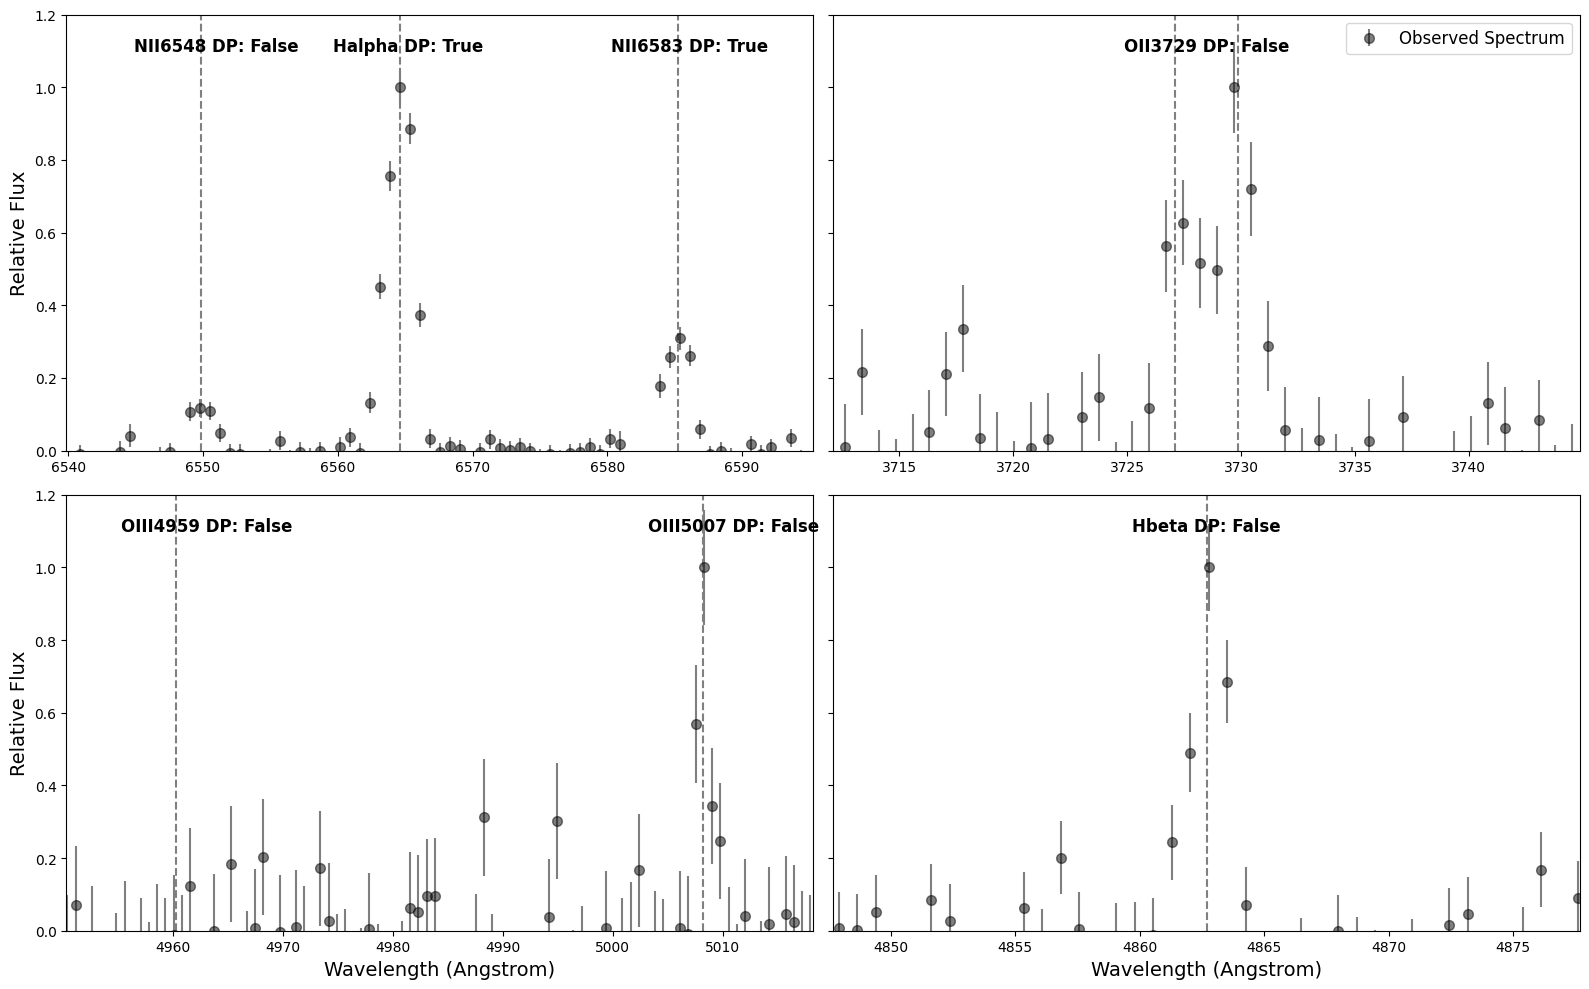

In [94]:
line_cols = ['OII3726', 'OII3729',
            'Hbeta',
            'OIII4959', 'OIII5007',
            'NII6548', 'Halpha', 'NII6583',
            'SII6716', 'SII6731']
lines = [*OII_rest, *Hbeta_rest, *OIII_rest, NII_rest[0], *Halpha_rest, NII_rest[1], *SII_rest]

# plt.figure(figsize=(12,6))

fig, axes = plt.subplots(2, 2, figsize=(16,10), sharey=True)
plt.subplots_adjust(wspace=-0.8)
axes = axes.flatten()

for i, ax in enumerate(axes):

    
    # plt.plot(lam, emission, label='Emission Line Only', color='orange', alpha=0.7)
    # plt.plot(lam, 3*sigma, label=r'3$\sigma$ Limit', color='red', linestyle='--')
    # plt.text(6550, 10, 'test', rotation=90, color='gray', fontsize=8)
    # ax.set_xlabel('Wavelength (Angstrom)')
    # ax.set_ylabel('Flux')
    if i == 0:
        ax.set_xlim([NII_rest[0]-10, NII_rest[1]+10])
        ax.set_ylabel('Relative Flux', fontsize=14)
    elif i == 1:
        ax.set_xlim([OII_rest[0]-15, OII_rest[1]+15])
    elif i == 2:
        ax.set_xlim([OIII_rest[0]-10, OIII_rest[1]+10])
        ax.set_xlabel('Wavelength (Angstrom)', fontsize=14)
        ax.set_ylabel('Relative Flux', fontsize=14)
    elif i == 3:
        ax.set_xlim([Hbeta_rest[0]-15, Hbeta_rest[0]+15])
        ax.set_xlabel('Wavelength (Angstrom)', fontsize=14)

    v_max = np.max(flux[(lam>ax.get_xlim()[0]) & (lam<ax.get_xlim()[1])])
    ax.set_ylim(bottom=0, top=1.2)

    ax.errorbar(lam, flux/v_max, yerr=sigma/v_max, label='Observed Spectrum', fmt='o', color='k', markersize=7, alpha=0.5)
    # ax.plot(lam, test_1comp/v_max, label='1-Comp Model', linewidth=3, color='purple')
    # ax.plot(lam, test_2comp_l/v_max, label='2-Comp Model (Left)', linestyle='--', linewidth=3, color='blue')
    # ax.plot(lam, test_2comp_r/v_max, label='2-Comp Model (Right)', linestyle='--', linewidth=3, color='red')
    # ax.plot(lam, test_2comp/v_max, label='2-Comp Model', linewidth=3, color='green')

    
    for i, line in enumerate(lines):

        if line < ax.get_xlim()[0] or line > ax.get_xlim()[1]:
            continue
        else:
            ax.axvline(x=line, color='gray', linestyle='--')
            if i != 0:
                line_label = f'{line_cols[i]} DP: {example_df[line_cols[i]+'_dp']}'
                if i != 2:
                    ax.text(line-5, 1.1, line_label, color='k', fontsize=12, weight='bold')
                else:
                    ax.text(line-3, 1.1, line_label, color='k', fontsize=12, weight='bold')
axes[1].legend(fontsize=12)

plt.tight_layout()

plt.show()
